In [1]:
from helper import *

# Load the full dataset that contains all the cities and populations, create new columns
full_dataset = pd.read_csv("../data/raw/SNIS_2020_raw.csv")
full_dataset['Attended Population'] = full_dataset['Attended Population (sewer)']
full_dataset['Served Population'] = full_dataset['Attended Population (sewer)']
full_dataset = full_dataset.fillna(0)

# Load all clean datasets (remember to re-run the clean_data.py code if the raw data files change)
snis_sewer, snis_water, ibnet_sewer, ibnet_water = load_datasets()

# Create cross-sectional versions of snis sewer and water
CS_YEAR = 2020
snis_sewer_cs, snis_water_cs = snis_sewer[snis_sewer['Year'] == CS_YEAR], snis_water[snis_water['Year'] == CS_YEAR]

# Create a version of the full dataset that is only CS_YEAR
full_dataset_CS = full_dataset[full_dataset['Year'] == CS_YEAR]

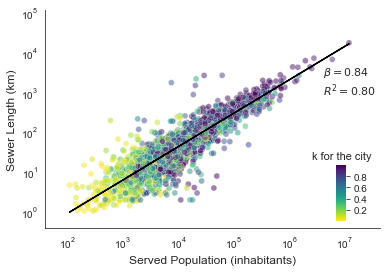

  0%|          | 0/100 [00:00<?, ?it/s]

In [2]:
# Calculate the beta for generalized model
beta_generalized = snis_cross_sectional_scaling(snis_sewer_cs, 'served')

# Estimate the full length for each city
full_length_no_growth, _, _, _ = simulate_full_bootstrap(snis_sewer_cs, full_dataset_CS, growth=False, n=100)

# Dictionary with the values of number of km per city
li_dict = full_length_no_growth[['City Code', 'Li']].reset_index(drop=True)
li_dict = {li_dict.iloc[i, 0]: li_dict.iloc[i, 1] for i in range(li_dict.shape[0])}

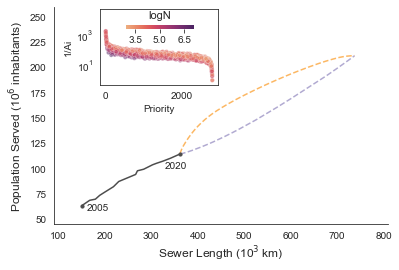

In [3]:
# If you need to generate the pickle file set this to false
LOAD_DATA = True

# Generate the plot that simulates the brazilian growth
x_range, efficiency_path, equality_path = growth_paths(full_dataset, snis_sewer, "../data/pickle/brazil_growth_data",
                                                       beta=beta_generalized, last_year=CS_YEAR, li_dict= li_dict,
                                                       load_data=LOAD_DATA, interpolation=1000, gini=False)